In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
# y = 3x + 2 + noise
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1)
y = 3 * X + 2 + np.random.randn(m, 1)

# Add bias term (column of 1s) to X for matrix multiplication
X_b = np.c_[np.ones((m, 1)), X]

class RidgeRegression_Scratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.theta = None
        
    def fit(self, X, y):
        # Closed-Form Solution: theta = (X^T * X + alpha * I)^-1 * X^T * y
        # This is strictly derived from setting the derivative of the Ridge Cost function to 0.
        
        A = np.eye(X.shape[1])
        # We typically do not regularize the bias term (first element), so set A[0,0] = 0
        A[0, 0] = 0 
        
        # The equation:
        # 1. X.T.dot(X): The Hessian (curvature) of the data
        # 2. self.alpha * A: The regularization term added to the diagonal
        # 3. np.linalg.inv(...): Inverting the regularized matrix
        self.theta = np.linalg.inv(X.T.dot(X) + self.alpha * A).dot(X.T).dot(y)
        
    def predict(self, X):
        return X.dot(self.theta)

class LassoRegression_Scratch:
    def __init__(self, alpha=1.0, max_iter=1000, tol=1e-4):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.theta = None
        
    def soft_threshold(self, rho, lam):
        # The "Soft Thresholding" operator is the heart of Lasso.
        # It forces small values immediately to zero.
        if rho < -lam:
            return rho + lam
        elif rho > lam:
            return rho - lam
        else:
            return 0.0

    def fit(self, X, y):
        # Algorithm: Cyclic Coordinate Descent
        # Lasso has no closed-form solution because |theta| is not differentiable at 0.
        # We optimize one coordinate (theta_j) at a time while holding others fixed.
        
        m, n = X.shape
        self.theta = np.zeros(n)
        
        for iteration in range(self.max_iter):
            theta_old = self.theta.copy()
            
            for j in range(n):
                # 1. Calculate the partial residual (error without feature j)
                # y_pred_others = Sum(theta_k * x_k) for all k != j
                X_j = X[:, j]
                y_pred = X.dot(self.theta)
                
                # The 'rho' is essentially the correlation between feature j and the residual
                # rho_j = x_j^T * (y - y_pred + theta_j * x_j)
                rho = X_j.dot(y.flatten() - y_pred + self.theta[j] * X_j)
                
                # 2. Apply Soft Thresholding
                # If feature j's correlation (rho) is weak, set coefficient to 0.
                if j == 0:
                    # Do not regularize the bias term
                    self.theta[j] = rho / (X_j.dot(X_j)) 
                else:
                    self.theta[j] = self.soft_threshold(rho, self.alpha) / (X_j.dot(X_j))
            
            # Check convergence
            if np.sum(np.abs(self.theta - theta_old)) < self.tol:
                break

    def predict(self, X):
        return X.dot(self.theta)

# --- Test the Code ---
# Ridge
ridge_scratch = RidgeRegression_Scratch(alpha=1.0)
ridge_scratch.fit(X_b, y)
print(f"Ridge Scratch Weights: {ridge_scratch.theta.flatten()}")

# Lasso
lasso_scratch = LassoRegression_Scratch(alpha=10.0) # High alpha to force sparsity if possible
lasso_scratch.fit(X_b, y)
print(f"Lasso Scratch Weights: {lasso_scratch.theta.flatten()}")

Ridge Scratch Weights: [2.28736241 2.69326395]
Lasso Scratch Weights: [2.48352284 2.48469439]


# Sklearn

--- Ridge Regression (L2) ---
Best Alpha found: 1.5999
Top 5 Coefficients: [2.83 2.55 2.58 2.54 3.14]
Noise Coefficient (Feature 49): -0.0073

--- Lasso Regression (L1) ---
Best Alpha found: 0.1111
Top 5 Coefficients: [2.8  2.6  2.59 2.38 3.1 ]
Noise Coefficient (Feature 49): -0.0000

Original Features: 50
Features selected by Lasso: 21

Ridge RMSE: 1.697
Lasso RMSE: 1.519


c:\Users\LEGION\anaconda3\envs\aibl\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1632: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


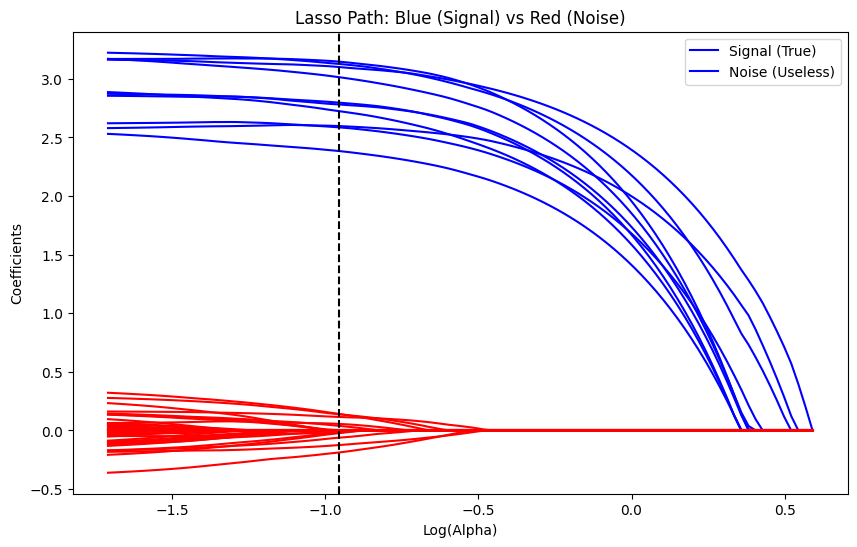

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. Generate "Sparse" Data
# We create a dataset with 50 features, but only 10 are actually informative.
# This simulates a real-world scenario where you have a lot of noise.
np.random.seed(42)
n_samples, n_features = 200, 50
X = np.random.randn(n_samples, n_features)

# Define the "True" weights: First 10 are 3.0, the rest are 0.0 (noise)
true_weights = np.zeros(n_features)
true_weights[:10] = 3.0

# y = X * w + noise
y = np.dot(X, true_weights) + np.random.normal(0, 1.5, size=n_samples)

# Split into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Standardization (MANDATORY for Regularization)
# Regularization penalizes the magnitude of weights. 
# If Feature A is in "millions" and Feature B is in "decimals", A's weight will naturally be small.
# Lasso might incorrectly keep B and drop A just because of the scale. 
# StandardScaler ensures all features compete on equal footing.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Apply same scaling to test set

# ==========================================
# 3. Ridge Regression with Built-in CV
# ==========================================
print("--- Ridge Regression (L2) ---")

# alphas: The list of values to test for the penalty strength.
# RidgeCV performs 'Leave-One-Out Cross-Validation' efficiently.
alphas_to_test = np.logspace(-2, 2, 50) # 50 values from 0.01 to 100
ridge_cv = RidgeCV(alphas=alphas_to_test, scoring='neg_mean_squared_error')

ridge_cv.fit(X_train_scaled, y_train)

print(f"Best Alpha found: {ridge_cv.alpha_:.4f}")
print(f"Top 5 Coefficients: {np.round(ridge_cv.coef_[:5], 2)}")
print(f"Noise Coefficient (Feature 49): {ridge_cv.coef_[49]:.4f}") 
# Note: Ridge shrinks noise coefs close to 0, but NOT exactly 0.

# ==========================================
# 4. Lasso Regression with Built-in CV
# ==========================================
print("\n--- Lasso Regression (L1) ---")

# LassoCV uses Coordinate Descent to find the best alpha over 5 folds.
lasso_cv = LassoCV(cv=5, random_state=42, alphas=None) # alphas=None lets sklearn pick the grid automatically

lasso_cv.fit(X_train_scaled, y_train)

print(f"Best Alpha found: {lasso_cv.alpha_:.4f}")
print(f"Top 5 Coefficients: {np.round(lasso_cv.coef_[:5], 2)}")
print(f"Noise Coefficient (Feature 49): {lasso_cv.coef_[49]:.4f}")
# Note: Lasso should set the noise coefficient to EXACTLY 0.0.

# ==========================================
# 5. Feature Selection Analysis
# ==========================================
# Let's verify if Lasso successfully removed the 40 useless features.
non_zero_features = np.sum(lasso_cv.coef_ != 0)
print(f"\nOriginal Features: {n_features}")
print(f"Features selected by Lasso: {non_zero_features}") 
# Ideally, this number should be close to 10.

# ==========================================
# 6. Evaluation
# ==========================================
y_pred_ridge = ridge_cv.predict(X_test_scaled)
y_pred_lasso = lasso_cv.predict(X_test_scaled)

print(f"\nRidge RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.3f}")
print(f"Lasso RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.3f}")

# Plotting the "Lasso Path" (Optional but very instructive)
# This shows how weights shrink as we increase alpha
from sklearn.linear_model import lasso_path

eps = 5e-3 # the smaller it is the longer the path
alphas_lasso, coefs_lasso, _ = lasso_path(X_train_scaled, y_train, eps=eps)

plt.figure(figsize=(10, 6))
colors = ['b'] * 10 + ['r'] * 40 # Blue for true features, Red for noise
for coef_l, c in zip(coefs_lasso, colors):
    plt.plot(np.log10(alphas_lasso), coef_l, c=c)

plt.xlabel("Log(Alpha)")
plt.ylabel("Coefficients")
plt.title("Lasso Path: Blue (Signal) vs Red (Noise)")
plt.axvline(np.log10(lasso_cv.alpha_), linestyle='--', color='k', label='Best Alpha')
plt.legend(['Signal (True)', 'Noise (Useless)'])
plt.show()

Detailed Explanation

scaler.fit_transform(X_train):Crucial Step: Regularization works by penalizing the size of the coefficients ($\beta$). If one feature has a range of 0 to 1,000,000 and another 0 to 1, the regression would naturally give the first feature a tiny coefficient to compensate. The penalty term would then unfairly crush the large feature's coefficient. Scaling puts them on the same playing field ($Mean=0, Var=1$).

RidgeCV(alphas=...):Instead of manually guessing Ridge(alpha=0.5), RidgeCV runs the regression multiple times.It uses "Generalized Cross-Validation" (GCV), which is a mathematical trick to estimate the Leave-One-Out error without actually training the model $N$ times. It is extremely fast.

LassoCV(cv=5):Lasso cannot use the GCV trick because it doesn't have a closed-form solution.It performs standard K-Fold Cross-Validation (here, 5-Fold). It splits the training data into 5 chunks, trains on 4, validates on 1, and repeats.Result: It finds the alpha that balances simplicity (fewer features) with accuracy.

lasso_path 
- Visualization:*This plot is the "signature" of Lasso.X-axis: The strength of regularization ($\alpha$). Left is weak, Right is strong.Y-axis: The value of the coefficients.
- Behavior: As you move right (higher alpha), the Red lines (noise features) hit zero and flatten out first. The Blue lines (true features) persist longer. This visually proves Lasso's ability to separate signal from noise.